In [ ]:
!ln -s "/content/drive/My Drive/tasks" tasks

In [ ]:
!mkdir -p utils
!mv *.py utils

Training

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import random

from utils.checkpoints import *
from utils.config import *
from utils.model import *
from utils.pca import *

In [ ]:
PRINT = 500
CHECKPOINT = 500

task_dir = "tasks/c59seed3"

seed, frac_train, layers, lr, n, weight_decay, betas, num_epochs = load_cfg(task_dir)

if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [ ]:
device

'cuda'

In [ ]:
def add(a: int, b: int) -> int:
    assert a >= 0 and a < n
    assert b >= 0 and b < n

    return (a+b)%n

# generate training and test data
# pick train samples at random from the multiplication table to form the training set
# use the whole multiplication table as the test set

test_x, test_y = [], []
for i in range(n*n):
    a = i%n
    b = i//n
    c = add(a, b)
    test_x.append([[1.0 if j == a else 0.0 for j in range(n)], [1.0 if j == b else 0.0 for j in range(n)]])
    test_y.append(c)

test_x = torch.tensor(test_x).to(device)
test_y = torch.tensor(test_y).to(device)

test_dataset = TensorDataset(test_x, test_y)
random.seed(seed)
train_dataset = torch.utils.data.Subset(test_dataset, random.sample(range(n*n), int(frac_train*n*n)))
train_dataloader = DataLoader(train_dataset, batch_size=len(train_dataset))

In [ ]:
lossfn = torch.nn.CrossEntropyLoss()

torch.manual_seed(seed)
model = MyModel(n, layers['embed_dim'], layers['hidden_dim']).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, betas=betas)

In [ ]:
_iter = range(num_epochs)
try:
    import tqdm

    _iter = tqdm.tqdm(_iter)
except ImportError: pass

for i in _iter:
    for train_x, train_y in train_dataloader:
        optimizer.zero_grad()

        y = model(train_x)
        loss = lossfn(y, train_y)
        loss.backward()

        optimizer.step()

        if (i % PRINT)*(i % CHECKPOINT) == 0:
            with torch.no_grad():
                y = model(test_x)
                loss_test = lossfn(y, test_y)
            if i % PRINT == 0: print(f"Epoch: {i} Training loss: {float(loss)} Test loss: {float(loss_test)}")
            if i % CHECKPOINT == 0: save_checkpoint(model, optimizer, {'train': float(loss), 'test': float(loss_test)}, task_dir, epoch=i)

  0%|          | 8/50000 [00:00<11:26, 72.82it/s]

Epoch: 0 Training loss: 4.079212188720703 Test loss: 4.07838773727417


  1%|          | 499/50000 [00:07<15:05, 54.64it/s]

Epoch: 500 Training loss: 0.008474341593682766 Test loss: 9.939793586730957


  2%|▏         | 998/50000 [00:15<10:09, 80.45it/s]

...

 98%|█████████▊| 49011/50000 [12:42<00:12, 77.15it/s]

Epoch: 49000 Training loss: 8.695768656252767e-07 Test loss: 5.4402349633164704e-05


 99%|█████████▉| 49516/50000 [12:49<00:07, 66.16it/s]

Epoch: 49500 Training loss: 8.689773949299706e-07 Test loss: 5.444380803965032e-05


100%|██████████| 50000/50000 [12:57<00:00, 64.31it/s]


Accuracy

In [ ]:
import numpy as np

def reduce_fourier(M, top=1):
    n = len(M)
    FFT = np.fft.rfft(M)
    FFTa = np.abs(FFT)
    idx = torch.topk(torch.from_numpy(FFTa), k=top).indices.tolist()

    FFTnew = np.zeros(len(FFT), dtype=np.csingle)
    for i in idx:
        FFTnew[i] = FFT[i]

    return np.fft.irfft(FFTnew, n)

def reduce_model(model, keepdims, top=1):
    embed = model.embed1.weight.shape[0]
    for l in [model.embed1, model.embed2]:
        old_weight=l.weight
        new_weight=old_weight-old_weight.mean(dim=1,keepdim=True)
        U, S, Vh = torch.linalg.svd(new_weight)
        rows = []
        for i in range(keepdims+1):
            row = Vh[i].detach().numpy()
            row = reduce_fourier(row, top)
            row = torch.from_numpy(row)
            row = S[i]*row
            rows.append(row.reshape(1,n))
        for i in range(keepdims+1,embed):
            row = torch.zeros(n)
            rows.append(row.reshape(1,n))
        Vh = torch.cat(rows)
        new_weight = U@Vh
        old_weight.data=torch.nn.parameter.Parameter(new_weight)

In [ ]:
import torch

from utils.accuracy import *
from utils.checkpoints import *
from utils.config import *
from utils.model import *

epoch = 49500
task = "tasks/c59seed2"

_, _, layers, _, n, _, _, _ = load_cfg(task)

model = MyModel(n, layers['embed_dim'], layers['hidden_dim'])
if epoch:
    load_checkpoint(model, None, task, epoch=epoch)
else:
    load_checkpoint(model, None, task, final=True)

reduce_model(model, 2, 1)

acc, incorrect = accuracy(model, n)
print(f"Accuracy: {acc}")

#for a,b,c,l in incorrect:
#    print(f"{a}+{b}:")
#    print(f"Answer: {c} Prediction: {l[0][0]}")
#    print(l)

Accuracy: 0.2252226371732261


Plotting

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from utils.checkpoints import *
from utils.config import *
from utils.figure_mpl import *
from utils.model import *
from utils.pca import *

dims=2
task = "tasks/c59seed0"

CHECKPOINT = 500

_, _, layers, _, n, _, _, num_epochs = load_cfg(task)

FRAMES = num_epochs//CHECKPOINT

model = MyModel(n, layers['embed_dim'], layers['hidden_dim'])

Mlist = []
for i in range(FRAMES):
    load_checkpoint(model, None, task, epoch=i*CHECKPOINT)
    model.eval()

    M, _ = pca(model.embed1.weight, dims=dims)

    Mlist.append(M.detach().numpy())

ani = draw_points_movie(Mlist, dims, [i*CHECKPOINT for i in range(FRAMES)])

ModuleNotFoundError: No module named 'utils'

In [ ]:
from matplotlib import rc
rc('animation', html='jshtml')

In [ ]:
ani

In [ ]:
from utils.checkpoints import *
from utils.config import *
from utils.figure_plotly import *
from utils.model import *
from utils.pca import *

dims = 3
epoch = 49000
task = "tasks/c59seed1"


_, _, layers, _, n, _, _, num_epochs = load_cfg(task)


model = MyModel(n, layers['embed_dim'], layers['hidden_dim'])
if epoch:
    epoch, loss = load_checkpoint(model, None, task, epoch=epoch)
else:
    epoch, loss = load_checkpoint(model, None, task, final=True)


M, _ = pca(model.embed1.weight, dims=dims)
#M, _ = pca(model.unembed.weight.data.transpose(0,1), dims=dims)
M = M.detach().numpy()

#fig = draw_points(M, dims, epoch, loss)
fig = draw_lines(M, dims, epoch, loss, aut=13)
fig

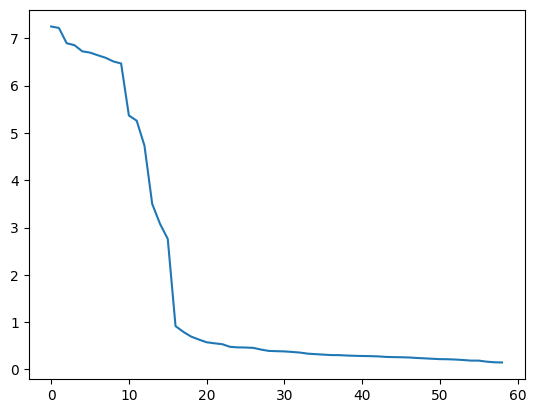

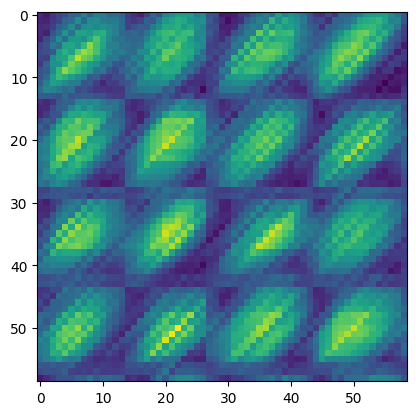

In [ ]:
from utils.checkpoints import *
from utils.config import *
from utils.model import *
import matplotlib.pyplot as plt
import plotly.express as px

dims = 3
epoch = 49000
task = "tasks/c59seed0"


_, _, layers, _, n, _, _, num_epochs = load_cfg(task)


model = MyModel(n, layers['embed_dim'], layers['hidden_dim'])
if epoch:
    epoch, loss = load_checkpoint(model, None, task, epoch=epoch)
else:
    epoch, loss = load_checkpoint(model, None, task, final=True)


fig, ax = plt.subplots()
im = ax.plot(S.detach().numpy())

for l in [model.embed1, model.embed2]:
  U, S, Vh = torch.linalg.svd(l.weight)
  S = torch.tensor([[S[0] if i == j and i <= 0 else 0.0 for i in range(n)] for j in range(layers['embed_dim'])])
  l.weight = torch.nn.parameter.Parameter(U@S@Vh)

input = torch.tensor([[[1.0 if j == (i//n) else 0.0 for j in range(n)], [1.0 if j == (i%n) else 0.0 for j in range(n)]] for i in range(n*n)])
with torch.no_grad():
    output3d = model(input)
output = torch.tensor([[float(output3d[a*n+b, (a+b)%n]) for a in range(n)] for b in range(n)])

output = output[[(16*i)%n for i in range(n)],:]
output = output[:,[(16*i)%n for i in range(n)]]

fig, ax = plt.subplots()
im = ax.imshow(output.detach().numpy())

#fig = px.scatter_3d(x=list(range(n))*(n**2), y=sorted(list(range(n))*n)*n, z=sorted(list(range(n))*(n**2)), size=[.1 for i in range(n**3)])
#fig

Looking at the Fourier Transform of PCA components

In [ ]:
from utils.checkpoints import *
from utils.config import *
from utils.model import *
import matplotlib.pyplot as plt
from utils.pca import *
import numpy as np

epoch = 49500
task = "tasks/c59seed0"


_, _, layers, _, n, _, _, num_epochs = load_cfg(task)


model = MyModel(n, layers['embed_dim'], layers['hidden_dim'])
if epoch:
    epoch, loss = load_checkpoint(model, None, task, epoch=epoch)
else:
    epoch, loss = load_checkpoint(model, None, task, final=True)

for l in range(3):
  embeds = [model.embed1, model.embed2, model.unembed]
  embeds = [e.weight for e in embeds]
  embeds[2] = embeds[2].transpose(0, 1)
  M, scores = pca(embeds[l], dims=10)
  M = M.detach().numpy()
  for pca_dim in range(6):
    print(f"Embed layer {l+1} PCA dimension {pca_dim+1} PCA score {scores[pca_dim]}")
    Mt = M[pca_dim]
    FFT = np.fft.fft(Mt.flatten())
    FFTa = np.abs(FFT[:n//2])
    top = 3
    idx = np.argpartition(FFTa, -top)[-top:][::-1]
    print("Top", np.array([np.fft.fftfreq(n)[idx[i]]*n for i in range(top)]))
    print("Abs", np.array([FFTa[idx[i]] for i in range(top)]))
    print("Angles", np.array([np.angle(FFT[idx[i]],deg=True) for i in range(top)]))
  print("")

Embed layer 1 PCA dimension 1 PCA score 7.249648094177246
Top [22.  4. 13.]
Abs [39.056633   3.6211724  1.9603287]
Angles [-107.69426   48.86641  139.68575]
Embed layer 1 PCA dimension 2 PCA score 7.217543601989746
Top [22. 13. 27.]
Abs [38.706894   3.8018806  3.5264478]
Angles [-18.143045 -61.428215  76.91954 ]
Embed layer 1 PCA dimension 3 PCA score 6.890269756317139
Top [27. 25. 13.]
Abs [37.280773   2.4094434  1.187035 ]
Angles [154.86388  -22.687037  84.48656 ]
Embed layer 1 PCA dimension 4 PCA score 6.850627899169922
Top [27. 13. 22.]
Abs [36.789112   3.5486407  3.1969573]
Angles [  64.57219   80.89523 -172.69946]
Embed layer 1 PCA dimension 5 PCA score 6.727104663848877
Top [ 4. 25. 13.]
Abs [35.276806   6.5202417  6.1817327]
Angles [-48.79078  135.87398  -44.573513]
Embed layer 1 PCA dimension 6 PCA score 6.698846340179443
Top [ 4. 13. 22.]
Abs [35.228313  7.039363  3.366122]
Angles [-138.31677    29.983288 -101.597885]

Embed layer 2 PCA dimension 1 PCA score 7.307475090026855

Visualizing activiating neurons

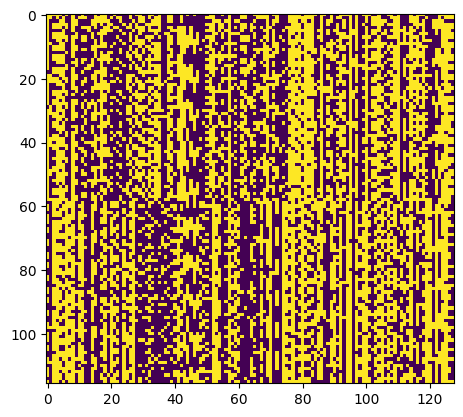

In [ ]:
from utils.checkpoints import *
from utils.config import *
from utils.model import *
import matplotlib.pyplot as plt
from utils.pca import *

epoch = 49000
task = "tasks/c59seed1"


_, _, layers, _, n, _, _, num_epochs = load_cfg(task)


model = MyModel(n, layers['embed_dim'], layers['hidden_dim'])
if epoch:
    epoch, loss = load_checkpoint(model, None, task, epoch=epoch)
else:
    epoch, loss = load_checkpoint(model, None, task, final=True)

x = torch.tensor([[[1.0 if j == (i//n) else 0.0 for j in range(n)], [1.0 if j == (i%n) else 0.0 for j in range(n)]] for i in range(n*n//30)])
a = model.embed1(x[:,0])
b = model.embed2(x[:,1])
x = torch.cat([a, b], dim=-1)
x = model.linear1(x)
x = torch.heaviside(x, torch.tensor([0.0]))

fig, ax = plt.subplots()
im = ax.imshow(x.detach().numpy())#, cmap='gray', vmin=0, vmax=255, aspect='auto')

Pizza logits

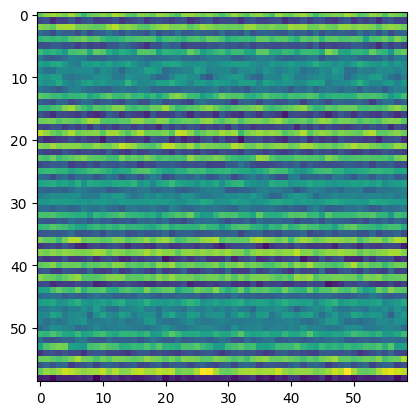

In [ ]:
from utils.checkpoints import *
from utils.config import *
from utils.model import *
import matplotlib.pyplot as plt
from utils.pca import *
import numpy as np

epoch = 49000
task = "tasks/c59seed2"


_, _, layers, _, n, _, _, num_epochs = load_cfg(task)


model = MyModel(n, layers['embed_dim'], layers['hidden_dim'])
if epoch:
    epoch, loss = load_checkpoint(model, None, task, epoch=epoch)
else:
    epoch, loss = load_checkpoint(model, None, task, final=True)

reduce_model(model, 1)

#freq = 22 # c59seed0
#freq = 5 # c59seed1
#freq = 12 # c59seed2
freq = 14 # c59seed3
#freq = 11 # c60seed0 # not auto
logits = np.zeros((n,n))
for a in range(n):
  for b in range(n):
    x = torch.tensor([[[1.0 if i == a else 0.0 for i in range(n)], [1.0 if i == b else 0.0 for i in range(n)]]])
    c = model(x)
    logits[(freq*(a+b))%n,(freq*(a-b))%n] = c[0][(freq*(a+b))%n]

fig, ax = plt.subplots()
im = ax.imshow(logits)